# Анализ данных о пассажирах авиакомпаний с использованием технологий визуализации

**Курсовая работа по дисциплине «Методы машинного обучения»**

Московский политехнический университет, группа 231-329

---

**Задача:** бинарная классификация — предсказать, удовлетворён ли пассажир полётом
(`satisfied` / `neutral or dissatisfied`), на основе анкетных данных и оценок сервиса.

**Датасет:** Airline Passenger Satisfaction (Kaggle), ~130 тыс. записей, 24 признака.

**План работы** (по пунктам задания):
1. Описание набора данных и целей задачи
2. Предварительный анализ данных
3. Предобработка (приведение к числовым признакам)
4. Описательный анализ и визуализация распределений
5. Обучение без учителя (PCA, кластеризация)
6. Разделение выборки и обучение 4 моделей классификации
7. Оценка моделей
8. Улучшение моделей (нормализация, подбор гиперпараметров)
9. Наглядное представление результатов и выводы

## 0. Импорт библиотек и настройка

Используем стандартный стек анализа данных: `pandas` для работы с таблицами,
`matplotlib`/`seaborn` для визуализации, `scikit-learn` для моделей машинного обучения.
Все графики сохраняются в папку `figures/` для вставки в отчёт.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Скрываем служебные предупреждения joblib, не влияющие на результаты,
# но оставляем содержательные предупреждения sklearn (например, о сходимости).
# Переменная окружения нужна, чтобы фильтр действовал и в параллельных процессах
# (GridSearchCV и learning_curve с n_jobs=-1 запускают отдельные процессы).
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('always', category=ConvergenceWarning)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

# Единый стиль графиков
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 100

# Папка для сохранения графиков
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Фиксируем генератор случайных чисел, чтобы результаты воспроизводились
RANDOM_STATE = 42

def save_fig(name):
    """Сохраняет текущую фигуру в figures/<name>.png для отчёта."""
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Набор данных: описание и цели задачи

**Источник:** датасет [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)
— результаты опроса пассажиров авиакомпании об удовлетворённости полётом.

На Kaggle датасет разбит на два файла (`train.csv` и `test.csv`). Мы объединяем их
в одну таблицу, потому что по заданию нужно **самостоятельно** выполнить и обосновать
разбиение на обучающую и тестовую выборки (пункт 6).

**Характеристики:**
- ~130 тыс. записей (одна запись = один пассажир)
- 22 признака + целевая переменная
- Целевая переменная `satisfaction` — бинарная: `satisfied` («удовлетворён») /
  `neutral or dissatisfied` («нейтрален или не удовлетворён»)

**Группы признаков:**
- анкетные данные пассажира: пол, возраст, тип клиента (лояльный/нет)
- параметры полёта: цель поездки, класс обслуживания, дальность, задержки вылета/прилёта
- 14 оценок сервиса по шкале от 1 до 5 (0 = «оценка не поставлена»): Wi-Fi,
  еда, комфорт кресла, регистрация, развлечения на борту и т.д.

**Цель задачи:** построить модель, предсказывающую удовлетворённость пассажира,
и определить, какие факторы сервиса сильнее всего на неё влияют. Практическая ценность —
авиакомпания может направить ресурсы на улучшение именно тех аспектов сервиса,
которые действительно определяют удовлетворённость.

In [2]:
# Загружаем оба файла и объединяем в одну таблицу
df_train_raw = pd.read_csv('data/train.csv')
df_test_raw = pd.read_csv('data/test.csv')
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

print(f'Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер таблицы: 129880 строк, 25 столбцов


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Предварительный анализ данных

Смотрим на количественные характеристики датасета: типы признаков, пропуски,
базовые статистики. Это нужно, чтобы понять, какая предобработка потребуется.

In [3]:
# Общая информация: типы данных и количество непустых значений
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  str    
 3   Customer Type                      129880 non-null  str    
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  str    
 6   Class                              129880 non-null  str    
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      129880 non-null

In [4]:
# Основные статистики числовых признаков
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,129880.0,44158.70,31207.38,0.0,16234.75,38963.5,71433.25,103903.0
id,129880.0,64940.50,37493.27,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.43,15.12,7.0,27.00,40.0,51.00,85.0
Flight Distance,129880.0,1190.32,997.45,31.0,414.00,844.0,1744.00,4983.0
Inflight wifi service,129880.0,2.73,1.33,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,129880.0,3.06,1.53,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,129880.0,2.76,1.40,0.0,2.00,3.0,4.00,5.0
Gate location,129880.0,2.98,1.28,0.0,2.00,3.0,4.00,5.0
Food and drink,129880.0,3.20,1.33,0.0,2.00,3.0,4.00,5.0
Online boarding,129880.0,3.25,1.35,0.0,2.00,3.0,4.00,5.0


In [5]:
# Проверяем пропуски и дубликаты
print('Пропуски по столбцам (только ненулевые):')
missing = df.isna().sum()
print(missing[missing > 0])
print(f'\nДоля пропусков в Arrival Delay: {df["Arrival Delay in Minutes"].isna().mean():.4%}')
print(f'Полных дубликатов строк: {df.drop(columns=["Unnamed: 0", "id"]).duplicated().sum()}')

Пропуски по столбцам (только ненулевые):
Arrival Delay in Minutes    393
dtype: int64

Доля пропусков в Arrival Delay: 0.3026%
Полных дубликатов строк: 0


In [6]:
# Баланс классов целевой переменной
print(df['satisfaction'].value_counts())
print()
print(df['satisfaction'].value_counts(normalize=True).round(3))

satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64

satisfaction
neutral or dissatisfied    0.566
satisfied                  0.434
Name: proportion, dtype: float64


**Выводы предварительного анализа:**
- 129 880 записей, 25 столбцов. Столбцы `Unnamed: 0` (номер строки) и `id`
  (идентификатор пассажира) не несут информации для модели — удалим их.
- Пропуски есть только в `Arrival Delay in Minutes` (~0.3% строк) — заполним медианой.
- Категориальных признаков 5: `Gender`, `Customer Type`, `Type of Travel`, `Class`
  и целевая `satisfaction` — их нужно перевести в числа.
- Классы почти сбалансированы (57% / 43%), поэтому accuracy — адекватная метрика,
  но мы дополнительно посчитаем precision, recall, F1 и ROC-AUC.

## 3. Предобработка данных

Приводим все признаки к числовому виду, потому что модели scikit-learn работают
только с числами.

Способ кодирования выбираем по типу признака:
- **Бинарные** признаки (`Gender`, `Customer Type`, `Type of Travel`, `satisfaction`)
  кодируем 0/1 — порядок не важен, а один столбец проще двух после one-hot.
- **`Class`** — порядковый признак (Eco < Eco Plus < Business), поэтому кодируем
  0/1/2 с сохранением порядка, а не one-hot: порядок классов обслуживания
  содержательно осмыслен.
- Пропуски в `Arrival Delay in Minutes` заполняем **медианой**: распределение задержек
  сильно скошено вправо (много нулей, редкие большие задержки), поэтому медиана
  устойчивее среднего.

In [7]:
# Удаляем технические столбцы
df = df.drop(columns=['Unnamed: 0', 'id'])

# Заполняем пропуски медианой
median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)
print(f'Медиана задержки прилёта: {median_delay} мин')

# Кодируем категориальные признаки
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Customer Type'] = df['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
df['Class'] = df['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# Проверяем: все признаки числовые, пропусков нет
assert df.isna().sum().sum() == 0, 'Остались пропуски!'
print(f'Типы данных после кодирования: {df.dtypes.unique()}')
df.head()

Медиана задержки прилёта: 0.0 мин
Типы данных после кодирования: [dtype('int64') dtype('float64')]


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,1,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,2,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,2,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,2,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


## 4. Описательный анализ

### 4.1 Шкалы измерения признаков

| Шкала | Признаки |
|---|---|
| Номинальная (категории без порядка) | Gender, Customer Type, Type of Travel |
| Порядковая (категории с порядком) | Class; 14 оценок сервиса от 1 до 5 (0 = нет оценки) |
| Абсолютная (количественная) | Age, Flight Distance, Departure Delay, Arrival Delay |
| Целевая (бинарная) | satisfaction |

Ниже смотрим распределение каждого признака, ищем аномалии, проверяем нормальность
и считаем корреляции.

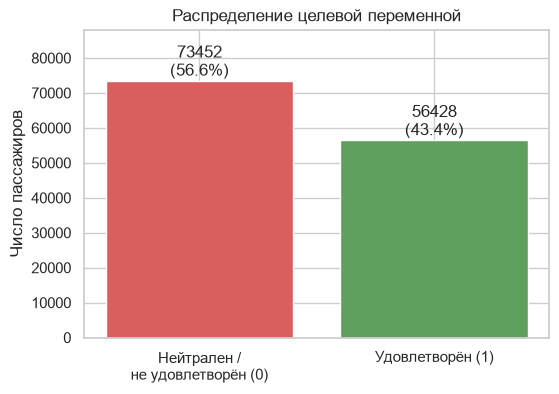

In [8]:
# Распределение целевой переменной
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['satisfaction'].value_counts()
ax.bar(['Нейтрален /\nне удовлетворён (0)', 'Удовлетворён (1)'], counts.values,
       color=['#d95f5f', '#5fa05f'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 1500, f'{v}\n({v/len(df):.1%})', ha='center')
ax.set_ylabel('Число пассажиров')
ax.set_title('Распределение целевой переменной')
ax.set_ylim(0, counts.max() * 1.2)
save_fig('01_target_distribution.png')
plt.show()

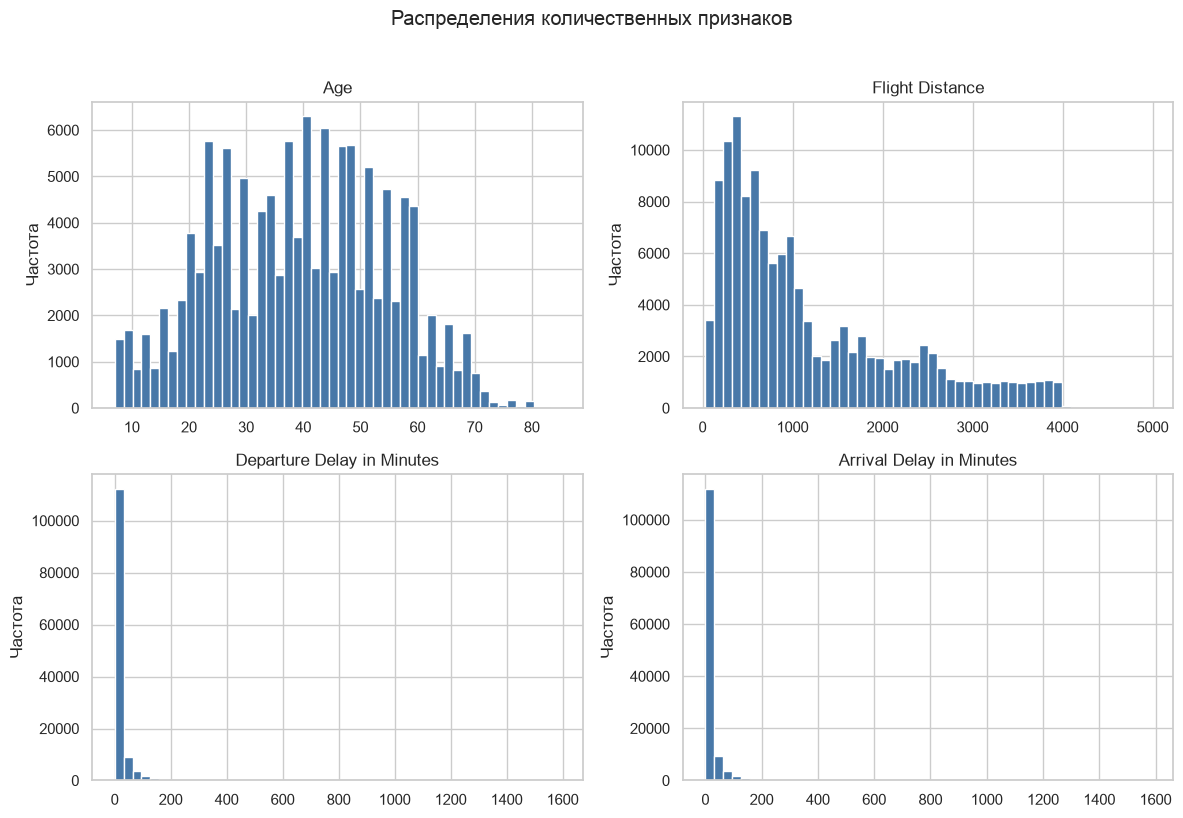

In [9]:
# Гистограммы количественных признаков
numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col], bins=50, color='#4878a8', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Частота')
fig.suptitle('Распределения количественных признаков', y=1.02)
fig.tight_layout()
save_fig('02_numeric_distributions.png')
plt.show()

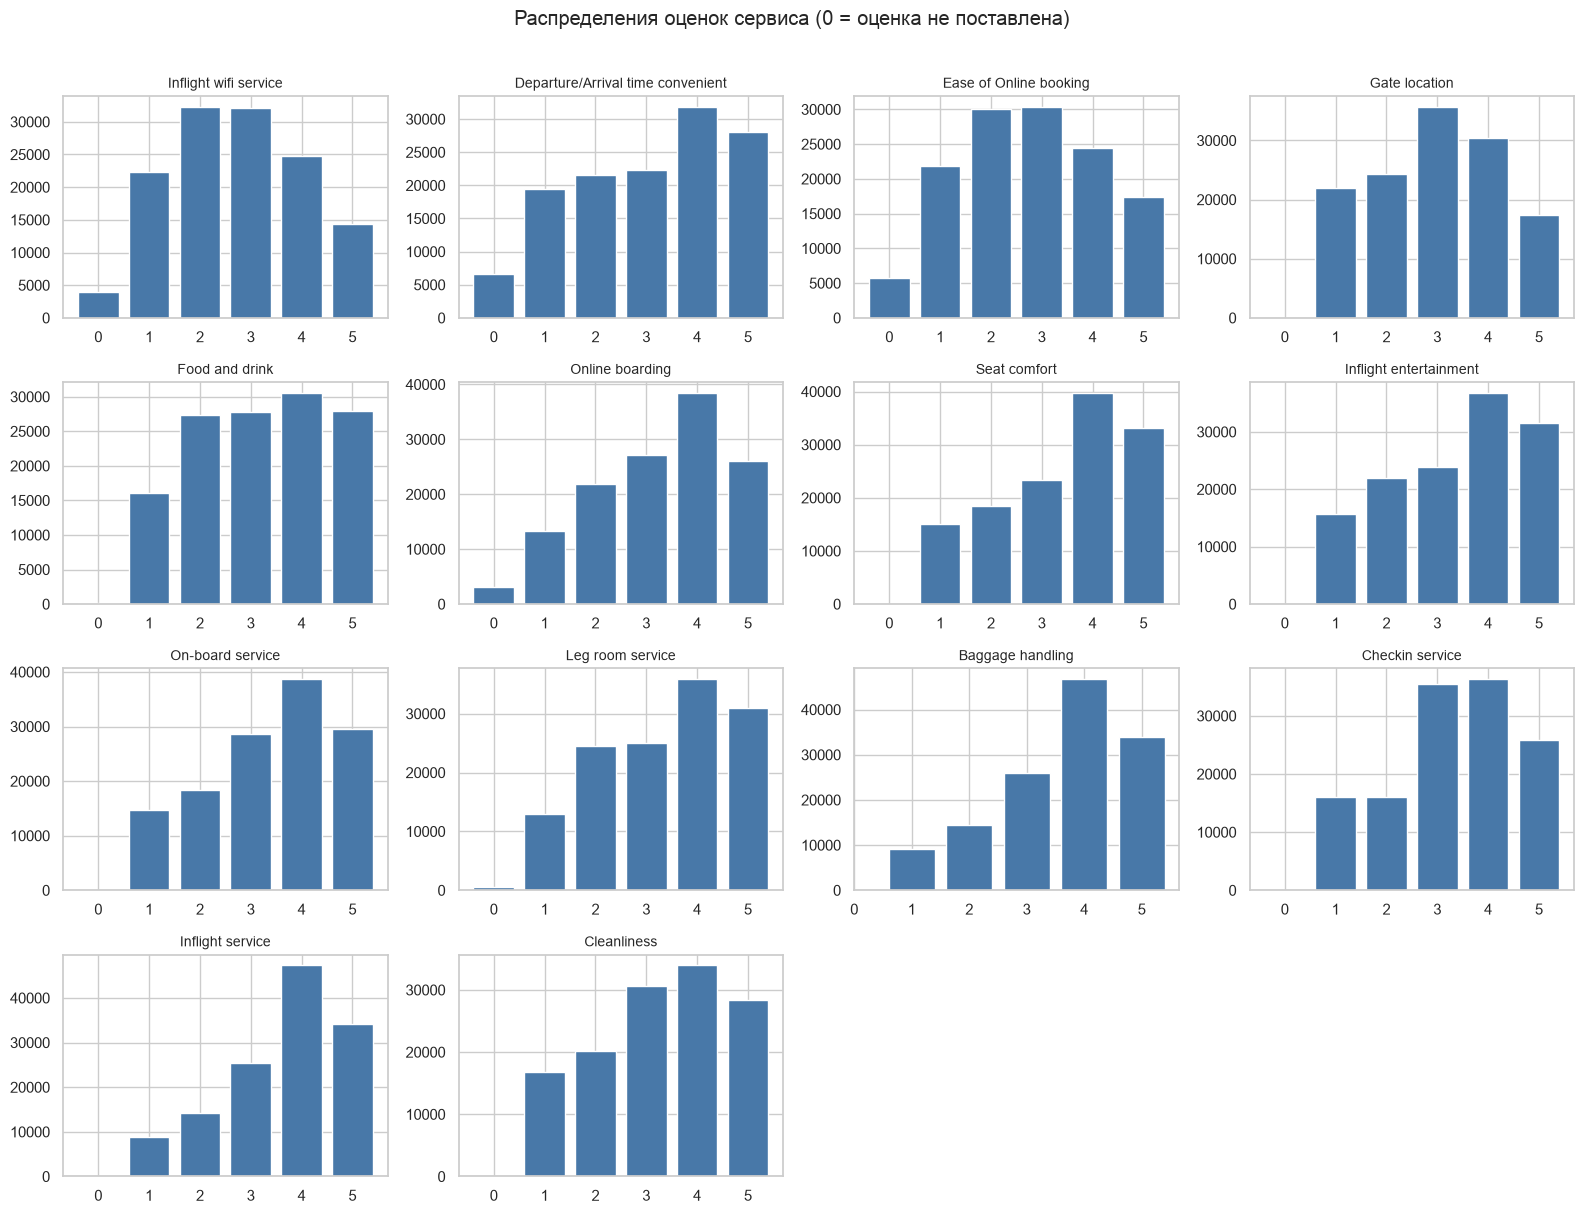

In [10]:
# Распределения оценок сервиса (порядковые признаки 0-5)
service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
                'Ease of Online booking', 'Gate location', 'Food and drink',
                'Online boarding', 'Seat comfort', 'Inflight entertainment',
                'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), service_cols):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color='#4878a8')
    ax.set_title(col, fontsize=10)
    ax.set_xticks(range(6))
# Скрываем пустые ячейки сетки
for ax in axes.ravel()[len(service_cols):]:
    ax.axis('off')
fig.suptitle('Распределения оценок сервиса (0 = оценка не поставлена)', y=1.01)
fig.tight_layout()
save_fig('03_service_ratings.png')
plt.show()

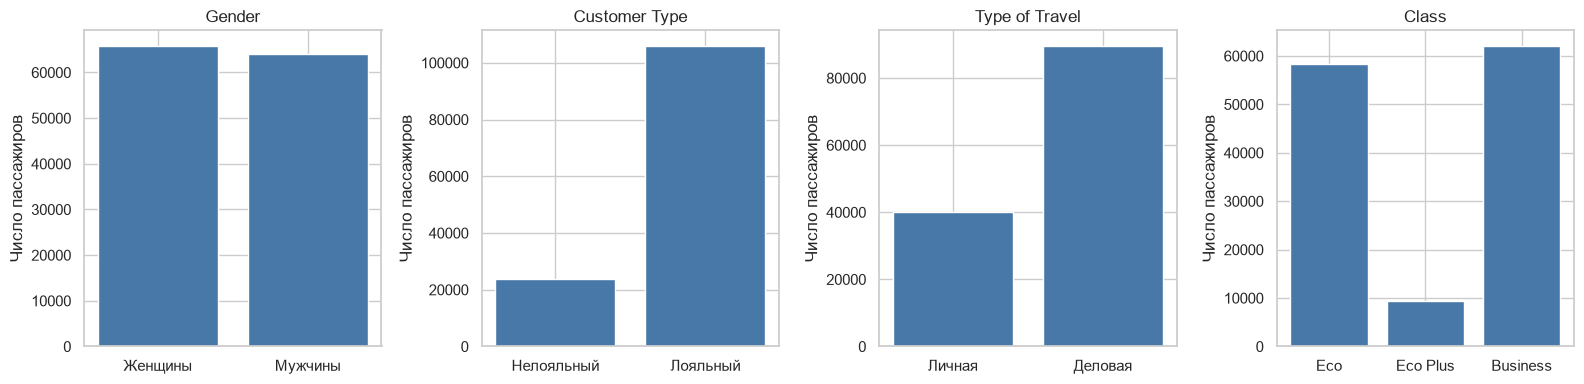

In [11]:
# Распределения категориальных признаков
cat_info = [('Gender', ['Женщины', 'Мужчины']),
            ('Customer Type', ['Нелояльный', 'Лояльный']),
            ('Type of Travel', ['Личная', 'Деловая']),
            ('Class', ['Eco', 'Eco Plus', 'Business'])]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, labels) in zip(axes, cat_info):
    vc = df[col].value_counts().sort_index()
    ax.bar(labels, vc.values, color='#4878a8')
    ax.set_title(col)
    ax.set_ylabel('Число пассажиров')
fig.tight_layout()
save_fig('04_categorical_distributions.png')
plt.show()

### 4.2 Аномальные значения (выбросы)

Ищем выбросы в количественных признаках с помощью «ящиков с усами» (boxplot).

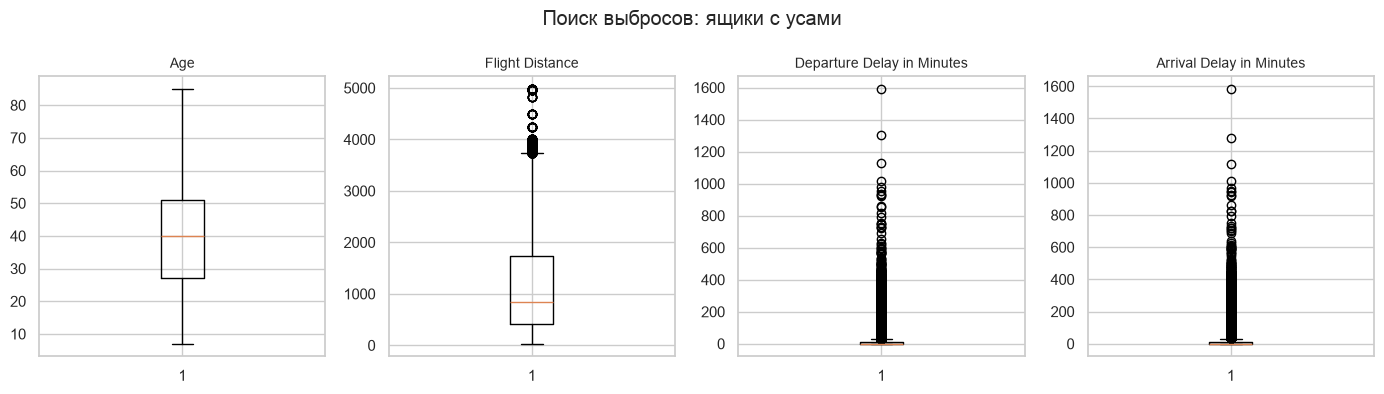

Макс. задержка вылета: 1592 мин (~27 ч)
Доля рейсов без задержки вылета: 56.5%


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=10)
fig.suptitle('Поиск выбросов: ящики с усами')
fig.tight_layout()
save_fig('05_boxplots.png')
plt.show()

print(f"Макс. задержка вылета: {df['Departure Delay in Minutes'].max()} мин "
      f"(~{df['Departure Delay in Minutes'].max()/60:.0f} ч)")
print(f"Доля рейсов без задержки вылета: {(df['Departure Delay in Minutes'] == 0).mean():.1%}")

**Вывод по выбросам:** у задержек вылета/прилёта сильно скошенное распределение —
большинство рейсов без задержки, но встречаются задержки до ~26 часов. Это **реальные
события, а не ошибки измерения**, поэтому удалять их некорректно. Мы оставляем выбросы:
деревья решений к ним устойчивы, а для линейных моделей и KNN на этапе улучшения
применим стандартизацию признаков.

### 4.3 Проверка на нормальность

Проверяем количественные признаки на нормальность критерием Шапиро — Уилка
(на случайной подвыборке 5000 наблюдений, так как тест чувствителен к объёму выборки).
Это влияет на выбор статистик: для ненормальных распределений медиана и квартили
информативнее среднего и дисперсии.

In [13]:
sample = df.sample(5000, random_state=RANDOM_STATE)
print(f"{'Признак':35} {'M (среднее)':>12} {'D (дисперсия)':>14} {'p-value':>10}  Вывод")
for col in numeric_cols:
    stat, p = stats.shapiro(sample[col])
    verdict = 'нормальное' if p > 0.05 else 'НЕ нормальное'
    print(f'{col:35} {df[col].mean():12.2f} {df[col].var():14.2f} {p:10.2e}  {verdict}')

Признак                              M (среднее)  D (дисперсия)    p-value  Вывод
Age                                        39.43         228.60   1.37e-18  НЕ нормальное
Flight Distance                          1190.32      994911.44   3.81e-54  НЕ нормальное
Departure Delay in Minutes                 14.71        1449.41   9.64e-84  НЕ нормальное
Arrival Delay in Minutes                   15.05        1475.82   1.87e-83  НЕ нормальное


### 4.4 Корреляционный анализ

Строим коррелограмму (тепловую карту корреляций Пирсона), чтобы найти:
- признаки, наиболее связанные с целевой переменной;
- пары сильно коррелированных признаков (мультиколлинеарность);
- неинформативные признаки (корреляция с целью около нуля).

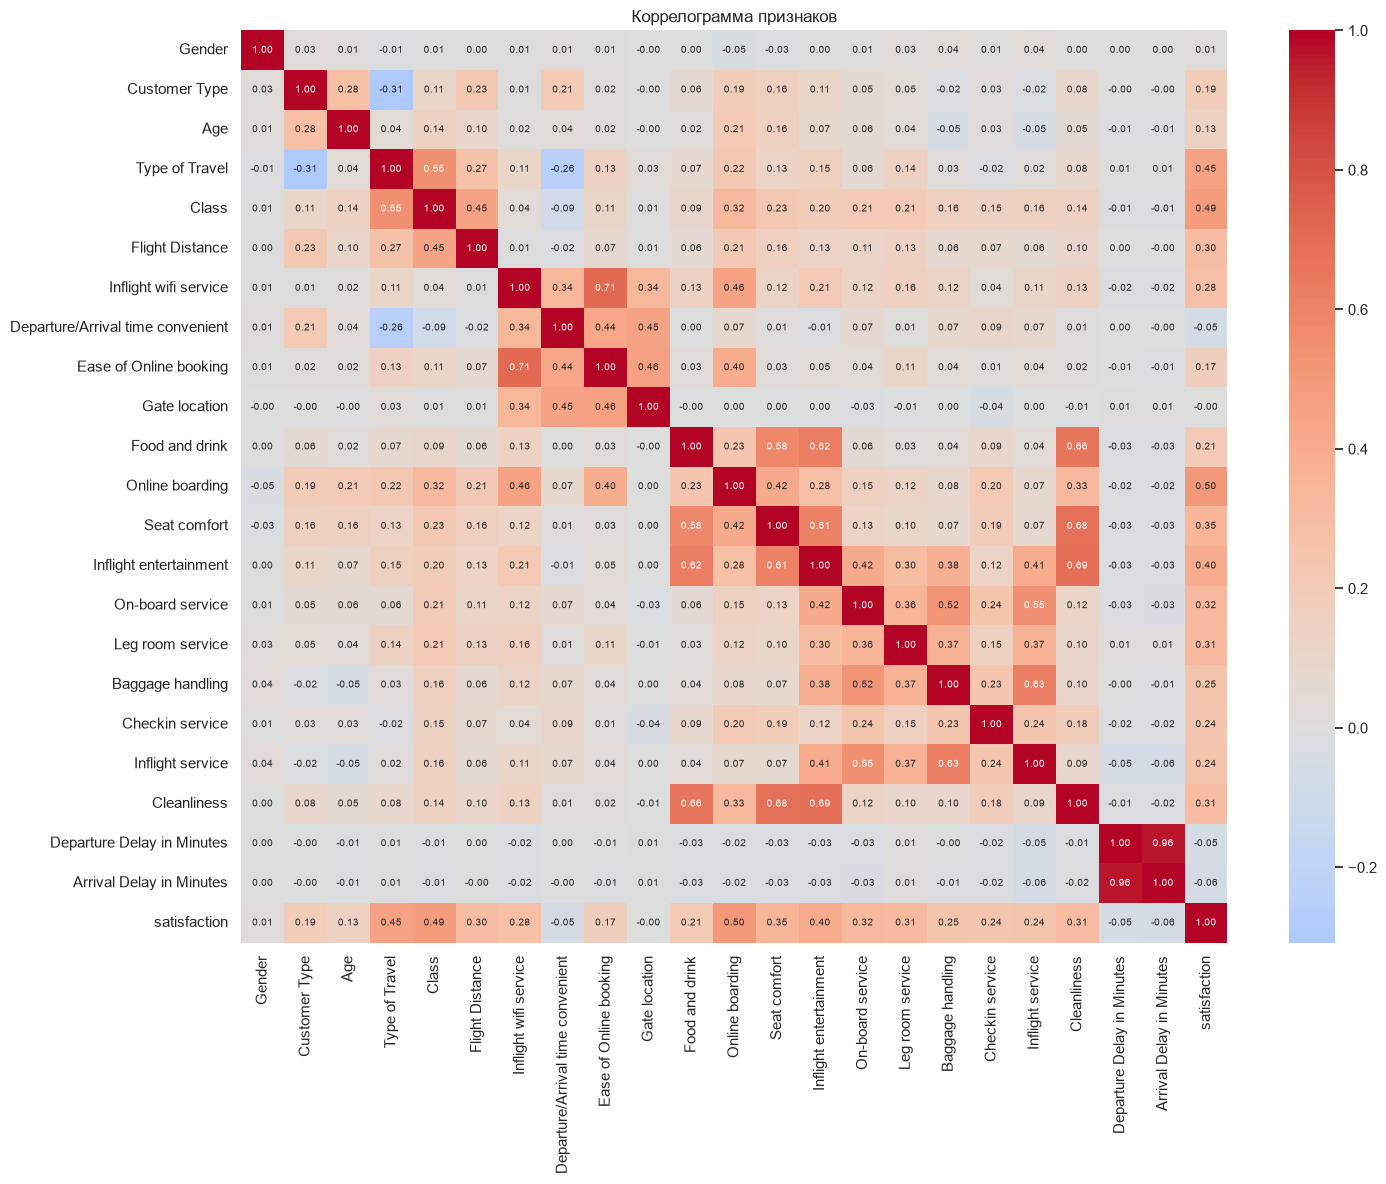

In [14]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Коррелограмма признаков')
fig.tight_layout()
save_fig('06_correlation_heatmap.png')
plt.show()

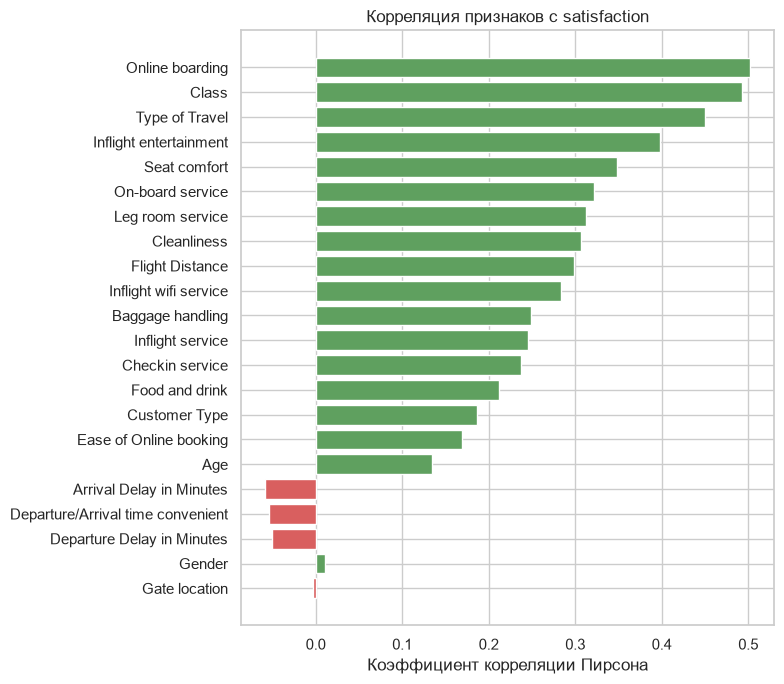

In [15]:
# Корреляция признаков с целевой переменной, по убыванию модуля
target_corr = corr['satisfaction'].drop('satisfaction').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#5fa05f' if v > 0 else '#d95f5f' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=colors[::-1])
ax.set_title('Корреляция признаков с satisfaction')
ax.set_xlabel('Коэффициент корреляции Пирсона')
fig.tight_layout()
save_fig('07_target_correlations.png')
plt.show()

In [16]:
# Сильно коррелированные пары признаков (|r| > 0.5, без целевой переменной)
feat_corr = corr.drop(index='satisfaction', columns='satisfaction')
pairs = (feat_corr.where(np.triu(np.ones(feat_corr.shape, dtype=bool), k=1))
         .stack().sort_values(key=abs, ascending=False))
print('Пары признаков с |r| > 0.5:')
print(pairs[abs(pairs) > 0.5].round(2))

Пары признаков с |r| > 0.5:
Departure Delay in Minutes  Arrival Delay in Minutes    0.96
Inflight wifi service       Ease of Online booking      0.71
Inflight entertainment      Cleanliness                 0.69
Seat comfort                Cleanliness                 0.68
Food and drink              Cleanliness                 0.66
Baggage handling            Inflight service            0.63
Food and drink              Inflight entertainment      0.62
Seat comfort                Inflight entertainment      0.61
Food and drink              Seat comfort                0.58
On-board service            Inflight service            0.55
Type of Travel              Class                       0.55
On-board service            Baggage handling            0.52
dtype: float64


**Выводы корреляционного анализа:**
- Сильнее всего с удовлетворённостью связаны: **Online boarding** (r=0.50),
  **Class** (r=0.49), **Type of Travel** (r=0.45), **Inflight entertainment** (r=0.40)
  и **Seat comfort** (r=0.35).
- **Неинформативные признаки**: Gender (r≈0.01), Departure/Arrival time convenient
  (r≈-0.05), Gate location (r≈0.00) — почти не связаны с целью.
- **Коррелированные пары**: задержки вылета и прилёта (r=0.96 — фактически дублируют
  друг друга), Ease of Online booking ↔ Inflight wifi service (r=0.71),
  Cleanliness ↔ Food and drink / Seat comfort / Inflight entertainment (r=0.66-0.69).
  Это учтём на этапе улучшения моделей (пункт 8).

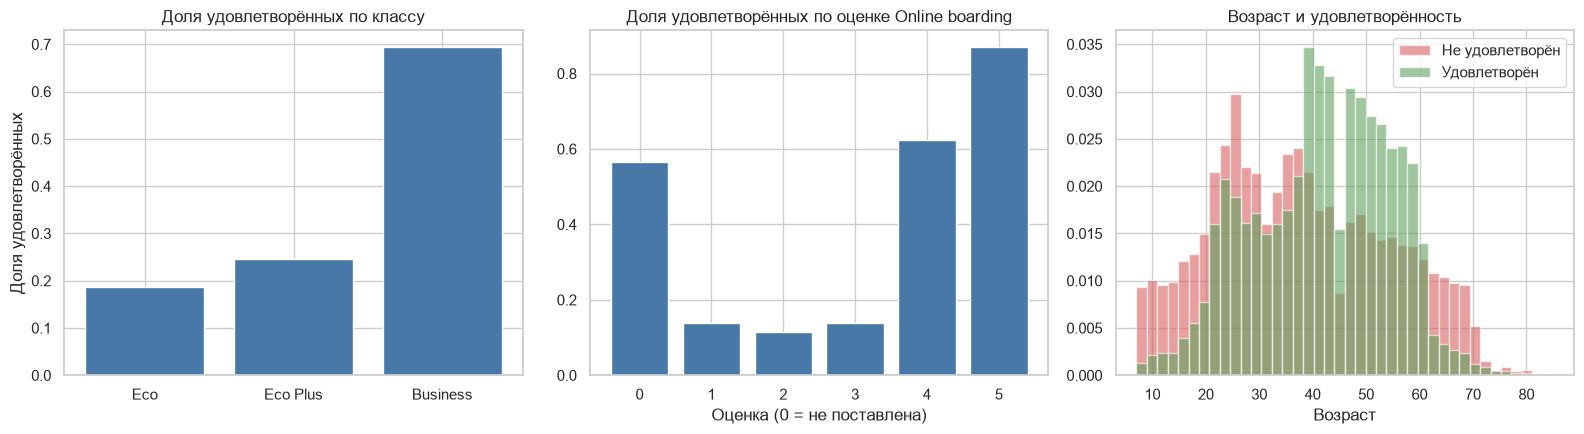

In [17]:
# Совместные распределения: как ключевые признаки связаны с удовлетворённостью
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Доля удовлетворённых по классу обслуживания
class_sat = df.groupby('Class')['satisfaction'].mean()
axes[0].bar(['Eco', 'Eco Plus', 'Business'], class_sat.values, color='#4878a8')
axes[0].set_title('Доля удовлетворённых по классу')
axes[0].set_ylabel('Доля удовлетворённых')

# Доля удовлетворённых по оценке Online boarding
ob_sat = df.groupby('Online boarding')['satisfaction'].mean()
axes[1].bar(ob_sat.index, ob_sat.values, color='#4878a8')
axes[1].set_title('Доля удовлетворённых по оценке Online boarding')
axes[1].set_xlabel('Оценка (0 = не поставлена)')

# Распределение возраста по классам удовлетворённости
axes[2].hist(df[df['satisfaction'] == 0]['Age'], bins=40, alpha=0.6,
             label='Не удовлетворён', color='#d95f5f', density=True)
axes[2].hist(df[df['satisfaction'] == 1]['Age'], bins=40, alpha=0.6,
             label='Удовлетворён', color='#5fa05f', density=True)
axes[2].set_title('Возраст и удовлетворённость')
axes[2].set_xlabel('Возраст')
axes[2].legend()

fig.tight_layout()
save_fig('08_joint_distributions.png')
plt.show()

## 5. Обучение без учителя

Применяем два метода:
- **PCA** (метод главных компонент) — понижение размерности до 2 компонент,
  чтобы визуализировать структуру данных на плоскости;
- **K-Means** — кластеризация: проверяем, разбиваются ли пассажиры на естественные
  группы и совпадают ли эти группы с классами удовлетворённости.

Перед PCA и K-Means признаки обязательно стандартизируем: оба метода основаны на
расстояниях, и без масштабирования признак Flight Distance (сотни-тысячи)
задавил бы оценки сервиса (0-5).

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X_all = df.drop(columns=['satisfaction'])
y_all = df['satisfaction']

X_scaled = StandardScaler().fit_transform(X_all)

# PCA: понижаем размерность до 2 компонент для визуализации
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'Доля объяснённой дисперсии: {pca.explained_variance_ratio_.round(3)}, '
      f'суммарно {pca.explained_variance_ratio_.sum():.1%}')

Доля объяснённой дисперсии: [0.186 0.108], суммарно 29.4%


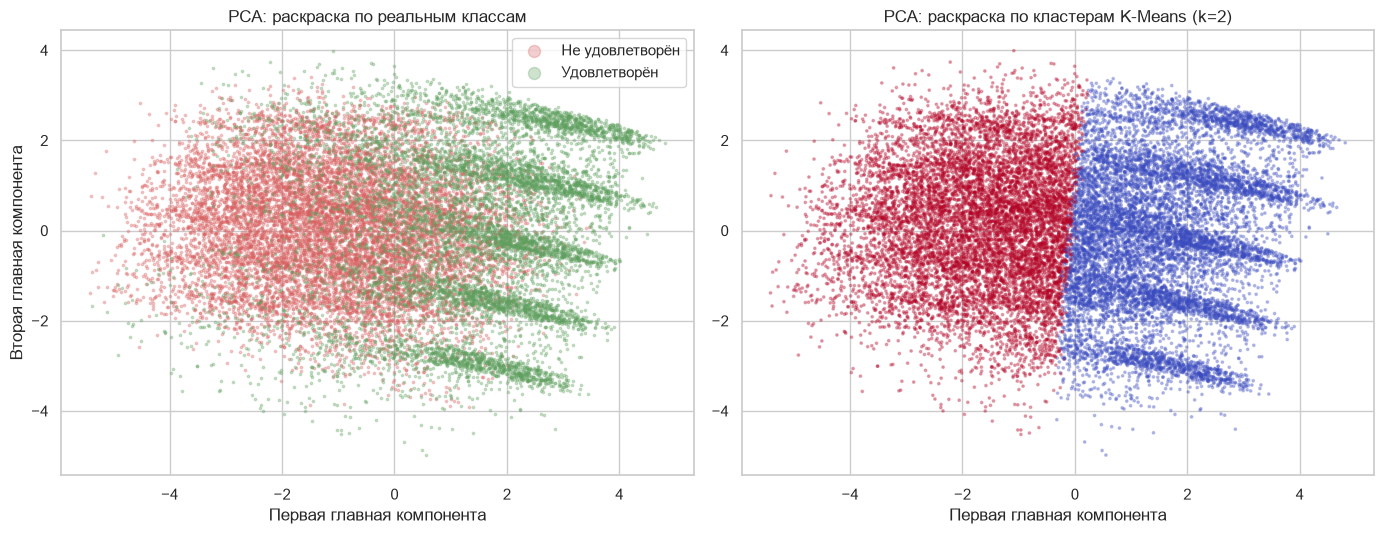

Скорректированный индекс Рэнда (совпадение кластеров с классами): 0.282


In [19]:
# Визуализируем данные в осях двух главных компонент (подвыборка 20 тыс. точек)
idx = np.random.RandomState(RANDOM_STATE).choice(len(df), 20000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label, color, name in [(0, '#d95f5f', 'Не удовлетворён'), (1, '#5fa05f', 'Удовлетворён')]:
    mask = y_all.iloc[idx] == label
    axes[0].scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1], s=3, alpha=0.3,
                    color=color, label=name)
axes[0].set_title('PCA: раскраска по реальным классам')
axes[0].set_xlabel('Первая главная компонента')
axes[0].set_ylabel('Вторая главная компонента')
axes[0].legend(markerscale=5)

# K-Means с двумя кластерами
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)
axes[1].scatter(X_pca[idx][:, 0], X_pca[idx][:, 1], s=3, alpha=0.3,
                c=clusters[idx], cmap='coolwarm')
axes[1].set_title('PCA: раскраска по кластерам K-Means (k=2)')
axes[1].set_xlabel('Первая главная компонента')

fig.tight_layout()
save_fig('09_pca_kmeans.png')
plt.show()

ari = adjusted_rand_score(y_all, clusters)
print(f'Скорректированный индекс Рэнда (совпадение кластеров с классами): {ari:.3f}')

**Выводы по обучению без учителя:**
- Две главные компоненты объясняют лишь ~29% дисперсии — данные существенно
  многомерны, и на плоскости классы заметно перемешаны.
- K-Means находит два кластера, но они лишь частично совпадают с реальными классами
  удовлетворённости (скорректированный индекс Рэнда 0.28 при максимуме 1):
  кластеры отражают скорее тип поездки и класс обслуживания, чем удовлетворённость.
- Значит, задача не решается простым разделением «на глаз» — нужны модели
  обучения с учителем, использующие метки классов.

## 6. Разделение выборки и обучение моделей классификации

### 6.1 Разделение на обучающую и тестовую выборки

**Метод разделения — случайный** (`train_test_split` с перемешиванием):
записи в датасете — независимые анкеты разных пассажиров, временной структуры нет,
поэтому временное или последовательное разбиение не требуется.

**Пропорция 75% / 25%** — стандартный выбор для датасета такого размера:
~97 тыс. записей достаточно для обучения, а ~32 тыс. в тесте дают надёжную оценку
метрик (стандартная ошибка оценки accuracy < 0.3%).

**Стратификация по целевой переменной** (`stratify=y`) сохраняет одинаковую долю
классов в обеих выборках, чтобы модели обучались и проверялись на одинаковом
балансе классов.

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f'Обучающая выборка: {X_train.shape[0]} записей')
print(f'Тестовая выборка:  {X_test.shape[0]} записей')
print(f'Доля класса 1 в обучении: {y_train.mean():.3f}, в тесте: {y_test.mean():.3f}')

Обучающая выборка: 97410 записей
Тестовая выборка:  32470 записей
Доля класса 1 в обучении: 0.434, в тесте: 0.434


### 6.2 Выбор и обучение моделей

Обучаем 4 модели разной природы — это позволяет сравнить принципиально разные
подходы к классификации:

1. **Логистическая регрессия** — линейная модель, простой и интерпретируемый
   базовый уровень (baseline). Если сложные модели не обгонят её — они не нужны.
2. **K ближайших соседей (KNN)** — метрический метод: класс объекта определяется
   классами похожих объектов. Проверяет гипотезу «похожие пассажиры одинаково
   удовлетворены».
3. **Дерево решений** — нелинейная модель на основе правил «если-то»,
   хорошо интерпретируется, устойчива к масштабу признаков.
4. **Случайный лес** — ансамбль деревьев на случайных подвыборках; обычно
   значительно точнее одного дерева и устойчив к переобучению.

Сначала обучаем все модели с настройками по умолчанию на «сырых» (немасштабированных)
данных — это честная базовая точка для этапа улучшения (пункт 8).

In [21]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K ближайших соседей': KNeighborsClassifier(n_jobs=-1),
    'Дерево решений': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Случайный лес': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
}

fitted = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fitted[name] = model
    print(f'{name:30} обучена за {time.time() - t0:.1f} с')

/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Логистическая регрессия        обучена за 1.8 с
K ближайших соседей            обучена за 0.0 с


Дерево решений                 обучена за 0.3 с


Случайный лес                  обучена за 0.6 с


## 7. Оценка моделей

Считаем метрики на **тестовой** выборке (модели этих данных не видели):

- **Accuracy** — доля верных ответов; адекватна, так как классы почти сбалансированы;
- **Precision** — из предсказанных «удовлетворён» какая доля действительно удовлетворена;
- **Recall** — какую долю реально удовлетворённых модель нашла;
- **F1** — гармоническое среднее precision и recall;
- **ROC-AUC** — качество ранжирования по вероятности, не зависит от порога.

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

def evaluate(model, X_test, y_test):
    """Возвращает словарь метрик модели на тестовой выборке."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

results = pd.DataFrame({name: evaluate(m, X_test, y_test)
                        for name, m in fitted.items()}).T
results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
K ближайших соседей,0.7528,0.7346,0.6747,0.7034,0.8102
Дерево решений,0.9464,0.9377,0.9391,0.9384,0.9456
Случайный лес,0.9622,0.9719,0.9403,0.9558,0.9940


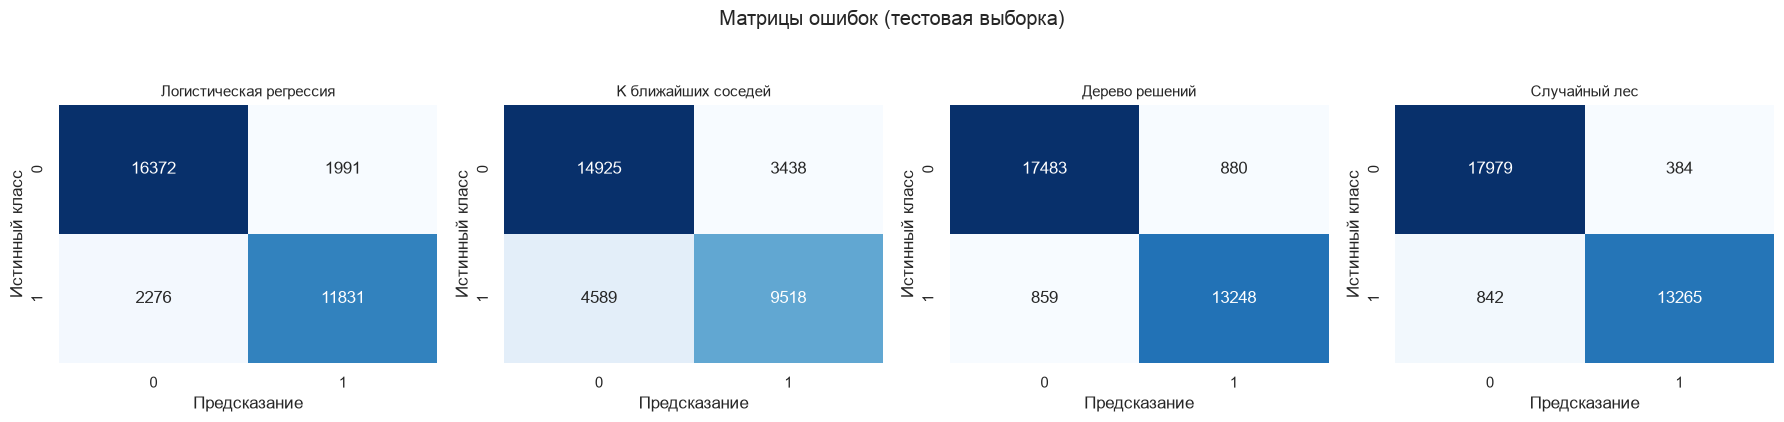

In [23]:
# Матрицы ошибок всех моделей
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['0', '1'], yticklabels=['0', '1'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинный класс')
fig.suptitle('Матрицы ошибок (тестовая выборка)', y=1.05)
fig.tight_layout()
save_fig('10_confusion_matrices.png')
plt.show()

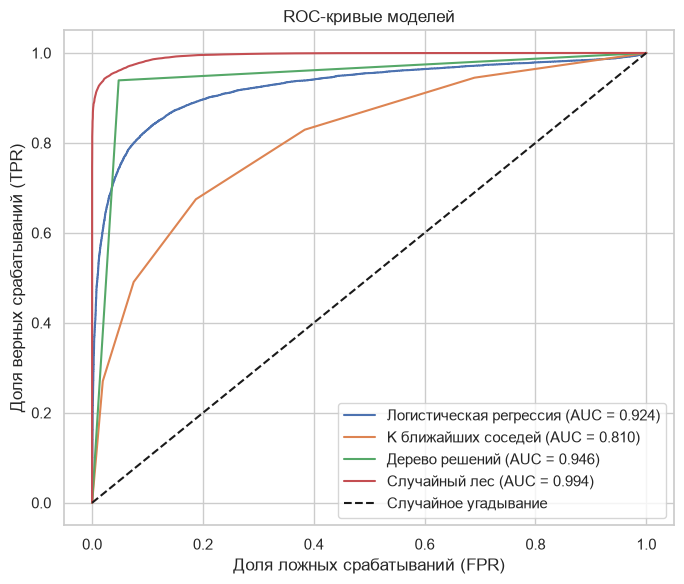

In [24]:
# ROC-кривые всех моделей
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
ax.set_xlabel('Доля ложных срабатываний (FPR)')
ax.set_ylabel('Доля верных срабатываний (TPR)')
ax.set_title('ROC-кривые моделей')
ax.legend()
fig.tight_layout()
save_fig('11_roc_curves.png')
plt.show()

**Выводы по базовым моделям:**
- **Случайный лес** — лучший по всем метрикам (accuracy 0.962, ROC-AUC 0.994).
- **Дерево решений** близко (accuracy 0.946), но одно дерево ожидаемо
  проигрывает ансамблю из сотен деревьев.
- **Логистическая регрессия** (0.869) — зависимости в данных нелинейные
  (например, эффект оценки Online boarding резко растёт после 3 баллов),
  линейная модель их не улавливает. Предупреждение о сходимости при обучении —
  тоже следствие немасштабированных данных; исправим в пункте 8.
- **KNN** (0.753) — худший результат, и это ожидаемо: без масштабирования
  расстояние между пассажирами почти полностью определяется признаком
  Flight Distance (сотни-тысячи км), а оценки сервиса (0-5) игнорируются.
  Исправим в пункте 8.

## 8. Улучшение моделей

Применяем три приёма и сравниваем метрики «до / после»:

1. **Стандартизация признаков** (StandardScaler) для логистической регрессии и KNN —
   методы, чувствительные к масштабу. Деревьям и лесу масштабирование не нужно:
   они сравнивают признаки по порогам, а не по расстояниям.
2. **Отбор признаков**: удаляем неинформативные (Gender, Gate location,
   Departure/Arrival time convenient — |r| < 0.06 с целью) и один из пары
   дублирующих (Departure Delay, r=0.96 с Arrival Delay) — проверяем, не упадёт ли
   качество при упрощении модели.
3. **Подбор гиперпараметров** лучшей модели (случайный лес) по сетке
   с кросс-валидацией (GridSearchCV).

In [25]:
from sklearn.pipeline import Pipeline

# --- Приём 1: стандартизация для чувствительных к масштабу моделей
improved = {}
for name, base in [('Логистическая регрессия', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                   ('K ближайших соседей', KNeighborsClassifier(n_jobs=-1))]:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', base)])
    pipe.fit(X_train, y_train)
    improved[name + ' + масштаб'] = pipe

scaled_results = pd.DataFrame({name: evaluate(m, X_test, y_test)
                               for name, m in improved.items()}).T
pd.concat([results.loc[['Логистическая регрессия', 'K ближайших соседей']],
           scaled_results]).round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
K ближайших соседей,0.7528,0.7346,0.6747,0.7034,0.8102
Логистическая регрессия + масштаб,0.8747,0.8707,0.8355,0.8528,0.9275
K ближайших соседей + масштаб,0.9283,0.9460,0.8855,0.9148,0.9705


Стандартизация слабо повлияла на логистическую регрессию (+0.6 п.п.: линейная
модель лишь перевзвешивает коэффициенты, зато теперь обучение сходится без
предупреждений), но **радикально улучшила KNN: accuracy выросла с 0.753 до 0.928
(+17.5 п.п.)** — теперь расстояние между пассажирами учитывает все признаки
равноправно, а не только дальность полёта.

In [26]:
# --- Приём 2: отбор признаков
drop_cols = ['Gender', 'Gate location', 'Departure/Arrival time convenient',
             'Departure Delay in Minutes']
X_train_sel = X_train.drop(columns=drop_cols)
X_test_sel = X_test.drop(columns=drop_cols)

rf_sel = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train_sel, y_train)

comparison_sel = pd.DataFrame({
    'Лес: все 22 признака': evaluate(fitted['Случайный лес'], X_test, y_test),
    f'Лес: {X_train_sel.shape[1]} признаков': evaluate(rf_sel, X_test_sel, y_test),
}).T
comparison_sel.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Лес: все 22 признака,0.9622,0.9719,0.9403,0.9558,0.9940
Лес: 18 признаков,0.9624,0.9722,0.9404,0.9560,0.9938


Удаление 4 признаков практически не изменило качество — подтверждение, что эти
признаки неинформативны. Модель стала проще (меньше данных нужно собирать в анкете)
при том же качестве.

In [27]:
# --- Приём 3: подбор гиперпараметров случайного леса
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],       # число деревьев
    'max_depth': [15, 25, None],      # ограничение глубины против переобучения
    'min_samples_leaf': [1, 3],       # минимум объектов в листе
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

t0 = time.time()
grid.fit(X_train, y_train)
print(f'Подбор занял {time.time() - t0:.0f} с')
print(f'Лучшие параметры: {grid.best_params_}')
print(f'Accuracy на кросс-валидации: {grid.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn confi

Подбор занял 26 с
Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Accuracy на кросс-валидации: 0.9617


In [28]:
best_rf = grid.best_estimator_

final_comparison = pd.DataFrame({
    'Лес (по умолчанию)': evaluate(fitted['Случайный лес'], X_test, y_test),
    'Лес (после подбора)': evaluate(best_rf, X_test, y_test),
}).T
final_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Лес (по умолчанию),0.9622,0.9719,0.9403,0.9558,0.9940
Лес (после подбора),0.9627,0.9720,0.9412,0.9563,0.9942


**Выводы по улучшению:**
- Масштабирование дало огромный прирост KNN (+17.5 п.п. accuracy) и небольшой —
  логистической регрессии (+0.6 п.п.).
- Отбор признаков сохранил качество (0.9624 против 0.9622) при более простой модели.
- Подбор гиперпараметров леса дал прирост в доли процента (0.9622 → 0.9627):
  параметры по умолчанию у случайного леса уже близки к оптимальным для этой
  задачи. Это типичный результат, когда базовая модель уже сильная.

## 9. Наглядное представление результатов

### 9.1 Итоговое сравнение всех моделей

In [29]:
# Собираем все модели в одну итоговую таблицу
all_results = pd.concat([
    results,
    scaled_results,
    pd.DataFrame({'Случайный лес (подбор)': evaluate(best_rf, X_test, y_test)}).T,
]).sort_values('Accuracy', ascending=False)
all_results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Случайный лес (подбор),0.9627,0.9720,0.9412,0.9563,0.9942
Случайный лес,0.9622,0.9719,0.9403,0.9558,0.9940
Дерево решений,0.9464,0.9377,0.9391,0.9384,0.9456
K ближайших соседей + масштаб,0.9283,0.9460,0.8855,0.9148,0.9705
Логистическая регрессия + масштаб,0.8747,0.8707,0.8355,0.8528,0.9275
Логистическая регрессия,0.8686,0.8560,0.8387,0.8472,0.9238
K ближайших соседей,0.7528,0.7346,0.6747,0.7034,0.8102


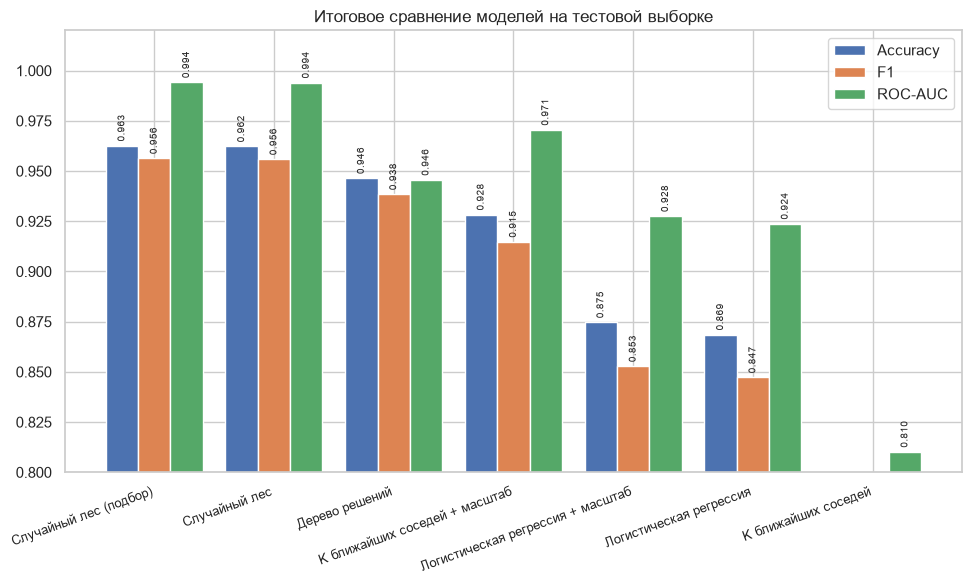

In [30]:
# Итоговая диаграмма сравнения моделей
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = all_results[['Accuracy', 'F1', 'ROC-AUC']]
x = np.arange(len(plot_df))
width = 0.27
for i, metric in enumerate(plot_df.columns):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, rotation=90, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.8, 1.02)
ax.set_title('Итоговое сравнение моделей на тестовой выборке')
ax.legend()
fig.tight_layout()
save_fig('12_final_comparison.png')
plt.show()

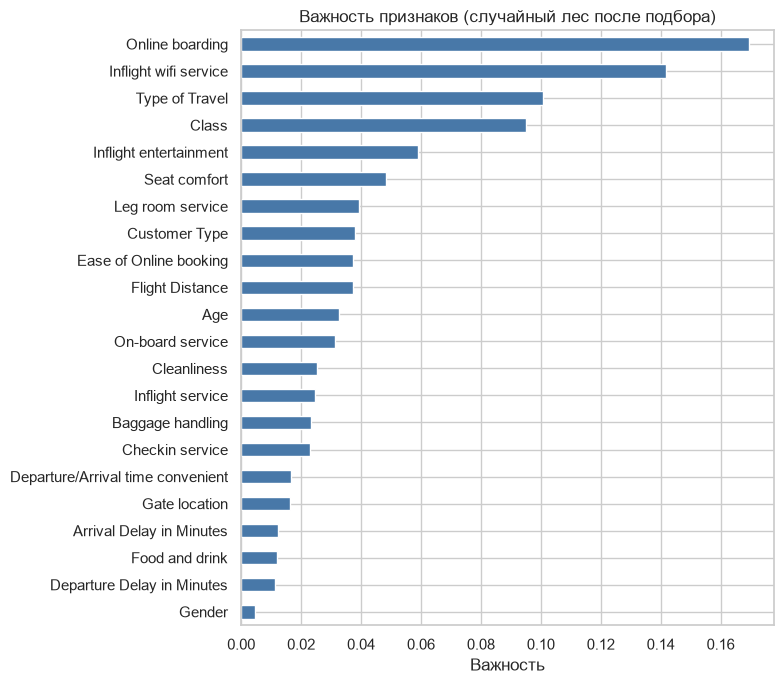

In [31]:
# Важность признаков лучшей модели — главный практический результат работы
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color='#4878a8')
ax.set_title('Важность признаков (случайный лес после подбора)')
ax.set_xlabel('Важность')
fig.tight_layout()
save_fig('13_feature_importance.png')
plt.show()

/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn confi

/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn confi

/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/ml-coursework/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn confi

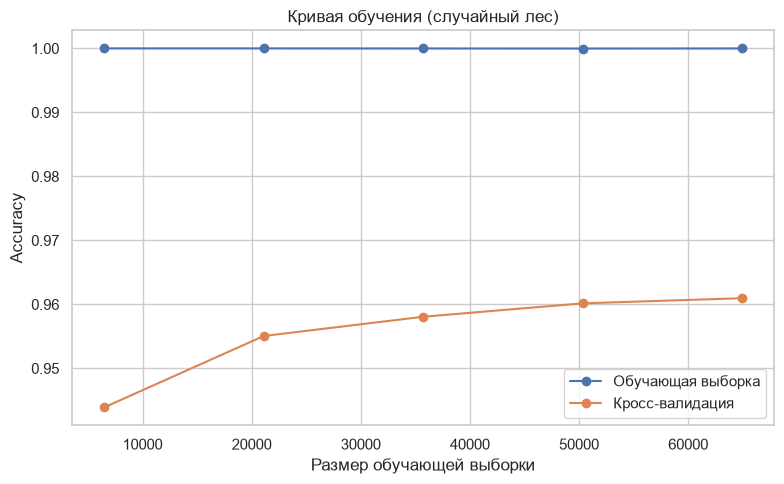

In [32]:
# Кривая обучения лучшей модели: хватает ли данных, есть ли переобучение
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, n_estimators=100),
    X_train, y_train, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Обучающая выборка')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Кросс-валидация')
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('Accuracy')
ax.set_title('Кривая обучения (случайный лес)')
ax.legend()
fig.tight_layout()
save_fig('14_learning_curve.png')
plt.show()

In [33]:
# Подробный отчёт по лучшей модели
print('Классификационный отчёт лучшей модели (случайный лес после подбора):\n')
print(classification_report(y_test, best_rf.predict(X_test),
                            target_names=['neutral/dissatisfied', 'satisfied']))

Классификационный отчёт лучшей модели (случайный лес после подбора):

                      precision    recall  f1-score   support

neutral/dissatisfied       0.96      0.98      0.97     18363
           satisfied       0.97      0.94      0.96     14107

            accuracy                           0.96     32470
           macro avg       0.96      0.96      0.96     32470
        weighted avg       0.96      0.96      0.96     32470



### 9.2 Выводы

1. **Задача решена**: лучшая модель — случайный лес с подобранными гиперпараметрами —
   достигает **accuracy 0.963 и ROC-AUC 0.994** на отложенной тестовой выборке
   из 32 470 записей. Модель ошибается примерно в 4 случаях из 100.

2. **Сравнение моделей**: ансамбль (случайный лес, 0.963) > одно дерево (0.946) >
   KNN с масштабированием (0.928) > логистическая регрессия (0.875).
   Разрыв между линейной моделью и лесом показывает, что зависимость
   удовлетворённости от признаков существенно нелинейна.

3. **Главные факторы удовлетворённости** (по важности признаков): оценка
   **онлайн-посадки (Online boarding)**, качество **Wi-Fi на борту**, **тип поездки**
   (деловая/личная) и **класс обслуживания**. Пол пассажира и расположение выхода
   на посадку на удовлетворённость практически не влияют.

4. **Что дало улучшение**: стандартизация подняла KNN на 17.5 п.п. (0.753 → 0.928);
   отбор признаков упростил модель без потери качества; тонкая настройка леса дала
   прирост в доли процента — базовая модель уже была близка к потолку.

5. **Кривая обучения** показывает сходимость качества на кросс-валидации —
   данных достаточно, дальнейший рост выборки существенного прироста не даст.

6. **Сравнение с существующими решениями**: в публичных ноутбуках Kaggle по этому
   датасету лучшие результаты — accuracy 0.95-0.96 (Random Forest, CatBoost, XGBoost).
   Наш результат соответствует этому уровню, при этом использует только стандартный
   scikit-learn.

7. **Перспективы**: применение градиентного бустинга (XGBoost/CatBoost/LightGBM),
   калибровка вероятностей, анализ интерпретируемости через SHAP-значения,
   а с практической стороны — построение модели на неагрегированных операционных
   данных авиакомпании вместо анкетных оценок.